# Demo: Controlled Pendulum System
## Complex Verification Scenario

- Strong algebraic coupling between drive and pendulum dynamics

In [1]:
import sys
import numpy as np
from pathlib import Path
import time
import scipy.io
from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent
from SysSimX.system.connection import Connection
from SysSimX.system.system import System
from SysSimX.viz.sysgraph import SystemGraphVisualizer

**Generate FMUComponents**

In [2]:
demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

fmu_paths

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


{'AngleEncoder': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu'),
 'Demo_Driven': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven.fmu'),
 'Demo_Driven_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven_Coupled.fmu'),
 'Drive': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive.fmu'),
 'Drive_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_Coupled.fmu'),
 'Drive_QStat': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_QStat.fmu'),
 'ImpactWall': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/ImpactWall.fmu'),
 'PID_Continuous': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Continuous.fmu'),
 'PID_Sampled': PosixPath('/home/flo/code/SystemSi

In [3]:
ref           = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Reference')
sensor_ref    = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state  = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid           = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive         = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
drive_coupled = FMUComponent(name='drive_coupled', fmu_path=fmu_paths['Drive_Coupled'], group='Actuator')
pendulum      = FMUComponent(name='pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

In [4]:
t = 0.0
dt = 0.001
t_end = 1

**1) Simple System without Algebraic Loop**

Execution Order (generations):
['pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']
['drive']

Algebraic Loops:


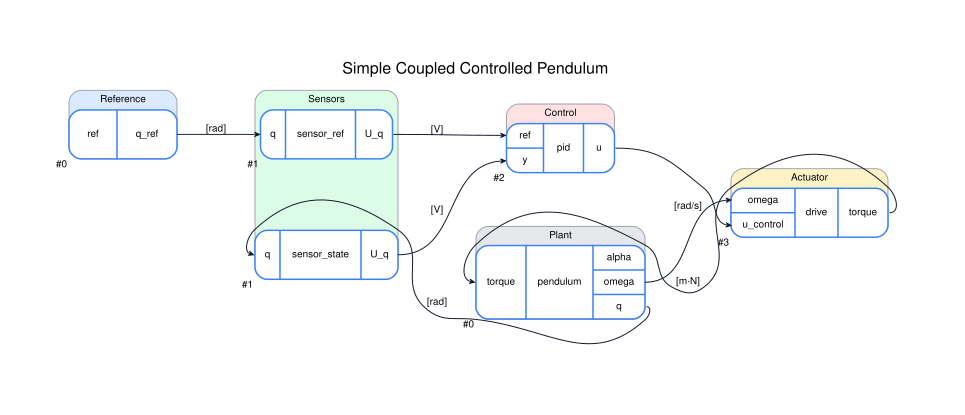

In [69]:
c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

system = System(name="Simple Coupled Controlled Pendulum")
for comp in components:
    system.add_component(comp)
for conn in connections:
    system.add_connection(conn)

simple_system = system
simple_system.compute_execution_order()

print("Execution Order (generations):")
for gen in simple_system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in simple_system.algebraic_loops:
    print(loop)

visualizer = SystemGraphVisualizer(simple_system)
visualizer.visualize()
visualizer.save("figures/ControlledPendulumSimple.svg")

**2) Complex System with Algebraic Loop**

Execution Order (generations):
['drive_coupled', 'pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']

Algebraic Loops:
['drive_coupled', 'pendulum']


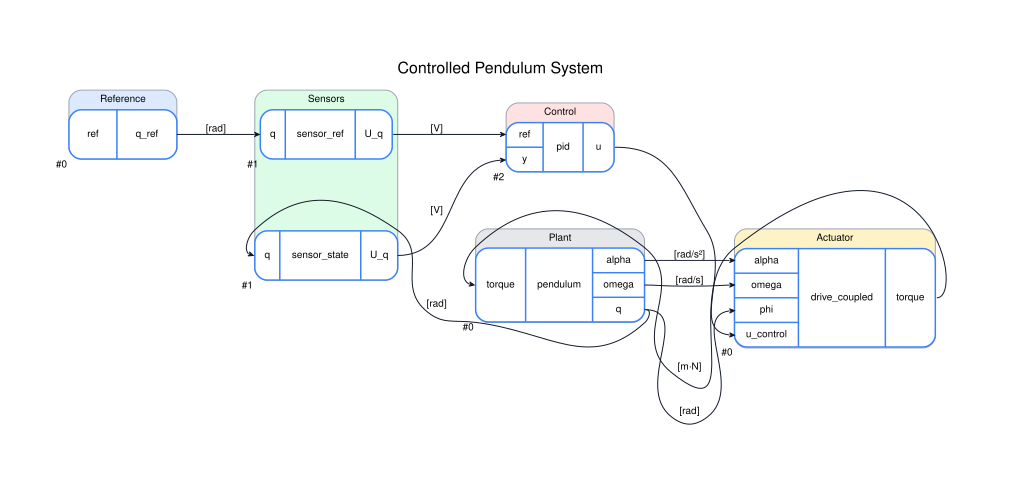

In [70]:
c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['u_control'].name)

c6 = Connection(src_comp=drive_coupled.name, src_port=drive_coupled.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7a = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['phi'].name)
c7b = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['omega'].name)
c7c = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['alpha'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['alpha'].name)

connections = [c1, c2, c3, c4, c5, c6, c7a, c7b, c7c]
components = [ref, sensor_ref, sensor_state, pid, drive_coupled, pendulum]

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

complex_system = system
complex_system.compute_execution_order()

print("Execution Order (generations):")
for gen in complex_system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in complex_system.algebraic_loops:
    print(loop)

visualizer = SystemGraphVisualizer(complex_system)
visualizer.visualize()
visualizer.save("figures/ControlledPendulumComplex.svg")

In [71]:
algorithms = ("Gauss-Seidel", "Jacobi", "IJCSA")
types = ("simple", "complex")
co_sim_systems = {types[0]: simple_system, types[1]: complex_system}
for sys_name, system in co_sim_systems.items():
    results = {}
    for algorithm in algorithms:
        t = 0.0
        system.algorithm = algorithm
        system.initialize(t, t_end=t_end)
        system.run(t0=0, tf=t_end, dt=dt)
        results[algorithm] = system.get_history()
    res_file = Path.cwd() / f'results/co_sim_{sys_name}.mat'
    scipy.io.savemat(str(res_file), results)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

**Monolithic Simulation for Reference from Modelica**

In [72]:
# Reference Modelica Simulation for Verification of the Co-Simulation Algorithm
# 1) Build the Modelica Model
pkg_dir_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum'
pkg_file_path = pkg_dir_path / 'package.mo'

models = ('ControlledPendulum.Demo_Driven', 'ControlledPendulum.Demo_Driven_Coupled')
types = ('simple', 'complex')

for model, type in zip(models, types):
    # 1) Create Modelica System Model
    model = ModelicaSystem(str(pkg_file_path), model)
    
    # 2) Set Simulation Options, Build and Simulate
    simulation_options = [
        f"startTime={0.0}",
        f"stopTime={t_end}",        
        f"stepSize={dt}",
        f"tolerance={1e-6}",
        f"solver=cvode"
        ]
    model.setOptimizationOptions(f"numberOfIntervals={int(t_end/dt)}")
    model.setSimulationOptions(simulation_options)
    model.buildModel()
    model.simulate()

    # 3) Extract and Save Results
    solutions_dict = {}
    solutions = model.getSolutions()
    for sol in solutions:
        solutions_dict[sol] = model.getSolutions(sol)
    res_file = Path.cwd() / f'results/monolithic_{type}.mat'
    scipy.io.savemat(str(res_file), solutions_dict)


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [73]:
res_ref_simple = scipy.io.loadmat(str(Path.cwd() / 'results/monolithic_simple.mat'))
res_ref_complex = scipy.io.loadmat(str(Path.cwd() / 'results/monolithic_complex.mat'))

res_co_sim_simple = scipy.io.loadmat(str(Path.cwd() / 'results/co_sim_simple.mat'))
res_co_sim_complex = scipy.io.loadmat(str(Path.cwd() / 'results/co_sim_complex.mat'))

In [74]:
cs_style = {'color': 'tab:blue', 'linestyle': 'None', 'marker': 'o', 'markersize': 4, 'label': 'Co-Simulation (FMUs with CVODE)'}
modelica_style = {'color': 'tab:orange', 'linestyle': 'None', 'marker': 'o', 'markersize': 2, 'label': 'Monolithic (Modelica with DASSL)'}
error_style = {'color': 'tab:red', 'linestyle': 'None', 'linewidth': 2, 'label': 'Error', 'marker': 'x', 'markersize': 4}

In [75]:
common_sytle = {'linestyle': 'None'}
simple_style = {'marker': 'o', 'markersize': 4}
complex_style = {'marker': 's', 'markersize': 2}
ref_simple_style = {'color': 'tab:orange', **common_sytle, 'label': 'Monolithic (simple)', **simple_style}
ref_complex_style = {'color': 'tab:green', **common_sytle, 'label': 'Monolithic (complex)', **complex_style}
cs_simple_style = {'color': 'tab:blue', **common_sytle, 'label': 'Co-Simulation (simple)', **simple_style}
cs_complex_style = {'color': 'tab:red', **common_sytle, 'label': 'Co-Simulation (complex)', **complex_style}

RMSE: 1.025e-04


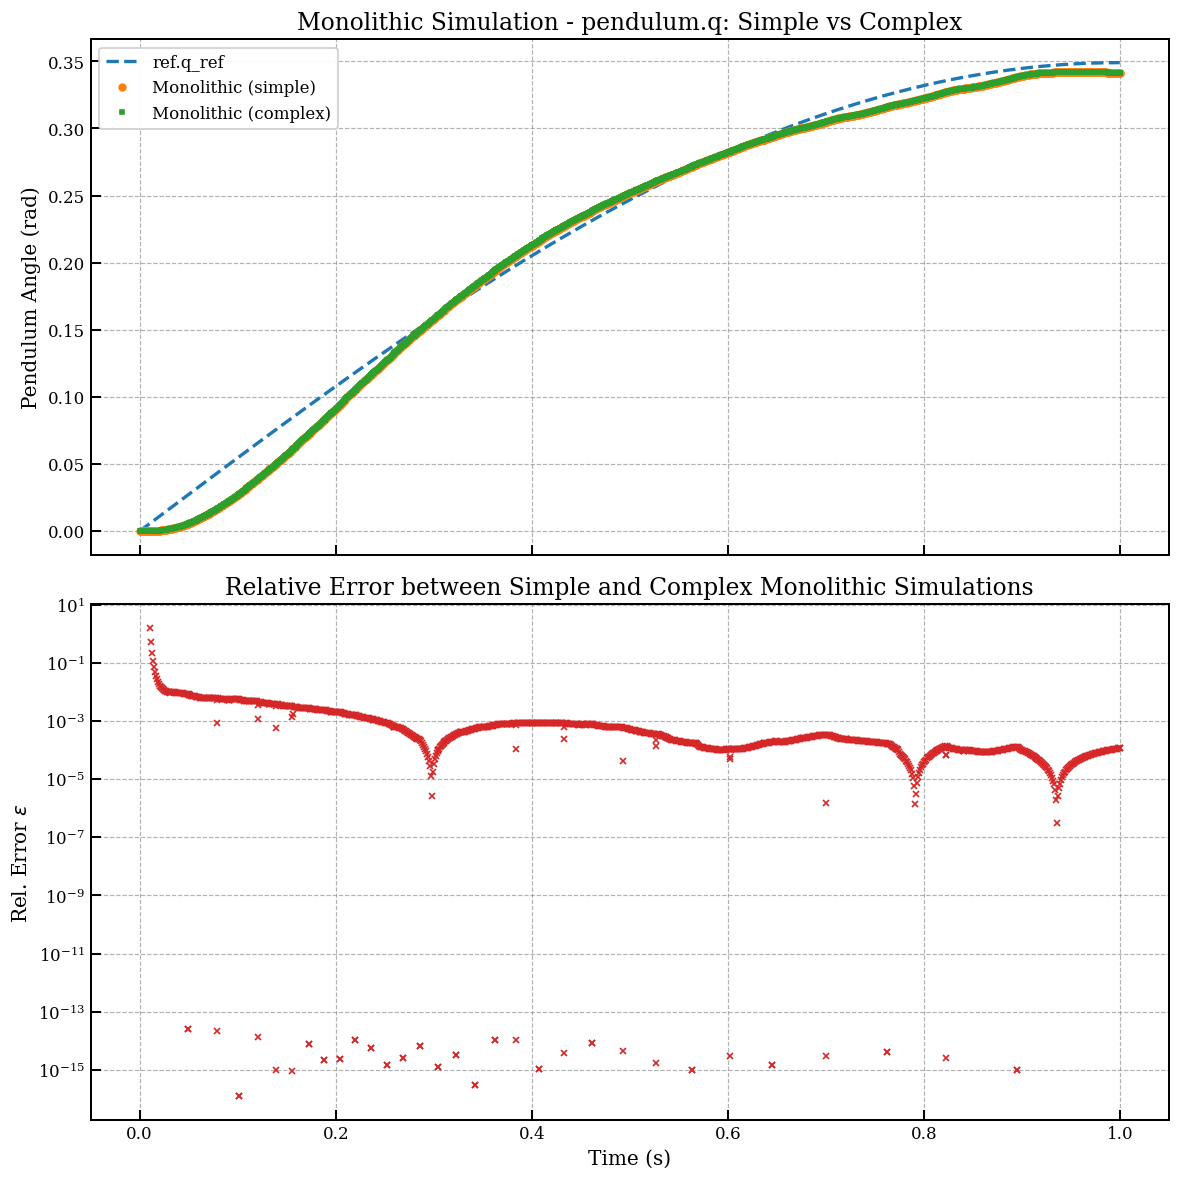

In [76]:
# Monolithic Comparison between Simple and Complex System
ref_time_simple = res_ref_simple['time'].flatten()
ref_time_complex = res_ref_complex['time'].flatten()
ref_q_ref = res_ref_simple['reference.q_ref'].flatten()
ref_q_pendulum_simple = res_ref_simple['pendulum.q'].flatten()
ref_q_pendulum_complex = res_ref_complex['pendulum.q'].flatten()

# Error: Simple vs Complex Monolithic
abs_error = np.abs(ref_q_pendulum_simple - ref_q_pendulum_complex)
eps = 1e-8
denom = np.maximum(np.abs(ref_q_pendulum_complex), eps)
rel_error = abs_error / denom
max_abs = np.max(abs_error)
rmse = np.sqrt(np.mean((ref_q_pendulum_simple - ref_q_pendulum_complex)**2))
max_rel = np.max(rel_error)
print(f"RMSE: {rmse:.3e}")

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
axs[0].set_title('Monolithic Simulation - pendulum.q: Simple vs Complex')
axs[0].plot(ref_time_simple, ref_q_ref, label='ref.q_ref', color='tab:blue', linestyle='--', linewidth=2)
axs[0].plot(ref_time_simple, ref_q_pendulum_simple, **ref_simple_style)
axs[0].plot(ref_time_complex, ref_q_pendulum_complex, **ref_complex_style)
axs[0].legend()
axs[0].grid()
axs[0].set_ylabel('Pendulum Angle (rad)')

axs[1].set_title('Relative Error between Simple and Complex Monolithic Simulations')
axs[1].semilogy(ref_time_simple, rel_error, **error_style)
axs[1].grid()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Rel. Error $\\epsilon$')

plt.tight_layout()
plt.show()


RMSE: 9.420e-05


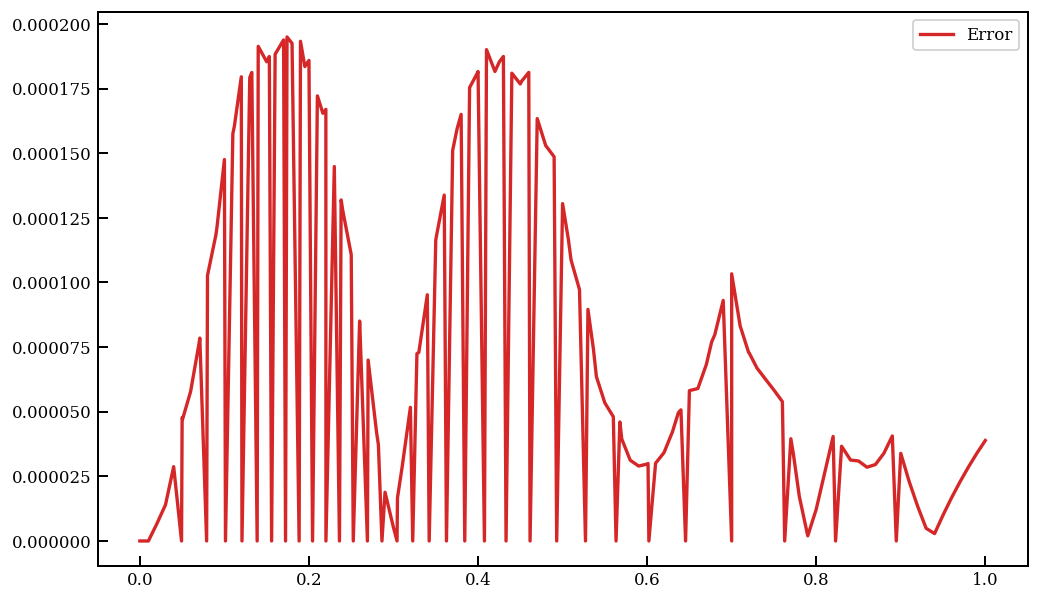

(array([0.        , 0.        , 0.        , 0.        , 0.00035374,
        0.00143526, 0.00148254, 0.00148254, 0.00318056, 0.00554399]),
 array([0.        , 0.        , 0.        , 0.        , 0.00034715,
        0.00142158, 0.00146853, 0.00146853, 0.00315182, 0.00554399]))

In [51]:
error_abs = np.abs(ref_q_pendulum_simple - ref_q_pendulum_complex)
plt.figure(figsize=(10, 6))
plt.plot(ref_time_simple, error_abs, **error_style)
plt.legend()
plt.show()


ref_q_pendulum_simple[:10], ref_q_pendulum_complex[:10]

In [22]:
t_vals_cs, q_ref_cs = zip(*ref.outputs['q_ref'].history)
t_vals_cs = np.array(t_vals_cs)
q_ref_cs = np.array(q_ref_cs)

t_vals_ref = np.array(results['time'])
q_ref_vals_ref = np.array(results['reference.q_ref'])
q_ref_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, q_ref_vals_ref)

denom = np.max(np.abs(q_ref_vals_ref_interp))
q_ref_error = (q_ref_cs - q_ref_vals_ref_interp) / denom

max_error = np.max(np.abs(q_ref_error))
print(f"Maximum relative error in q_ref: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, q_ref_cs, **cs_style)
plt.plot(t_vals_ref, q_ref_vals_ref, **modelica_style)
plt.xlabel('Time $(s)$')
plt.ylabel('Reference Angle $q_{ref}$ (rad)')
plt.title('Reference Angle $q_{ref}$')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'time'

Maximum absolute error in Uq_ref: 0.000e+00


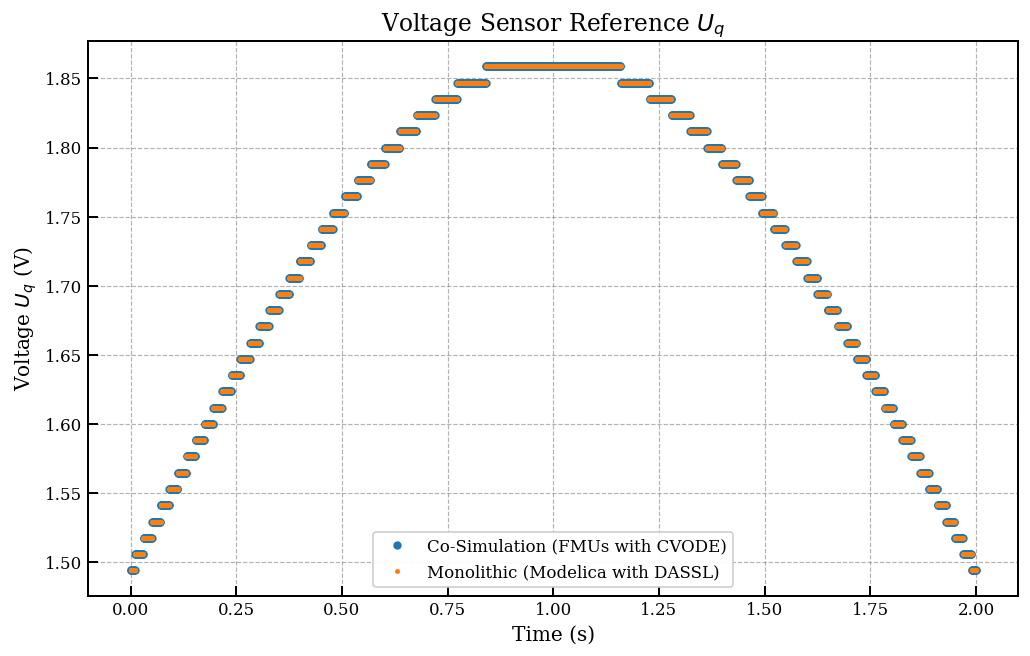

In [ ]:
# Sensor Ref Uq
t_vals_cs, Uq_ref_cs = zip(*sensor_ref.outputs['U_q'].history)
t_vals_cs = np.array(t_vals_cs)
Uq_ref_cs = np.array([val.magnitude for val in Uq_ref_cs])

t_vals_ref = np.array(results['time'])
Uq_ref_ref = np.array(results['sensor_ref.U_q'])

Uq_ref_ref_interp = np.interp(t_vals_cs, t_vals_ref, Uq_ref_ref)
Uq_ref_error = Uq_ref_cs - Uq_ref_ref_interp
max_error = np.max(np.abs(Uq_ref_error))
print(f"Maximum absolute error in Uq_ref: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, Uq_ref_cs, **cs_style)
plt.plot(t_vals_ref, Uq_ref_ref, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel('Voltage $U_{q}$ (V)')
plt.title('Voltage Sensor Reference $U_{q}$')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in Uq_state: 6.329e-03


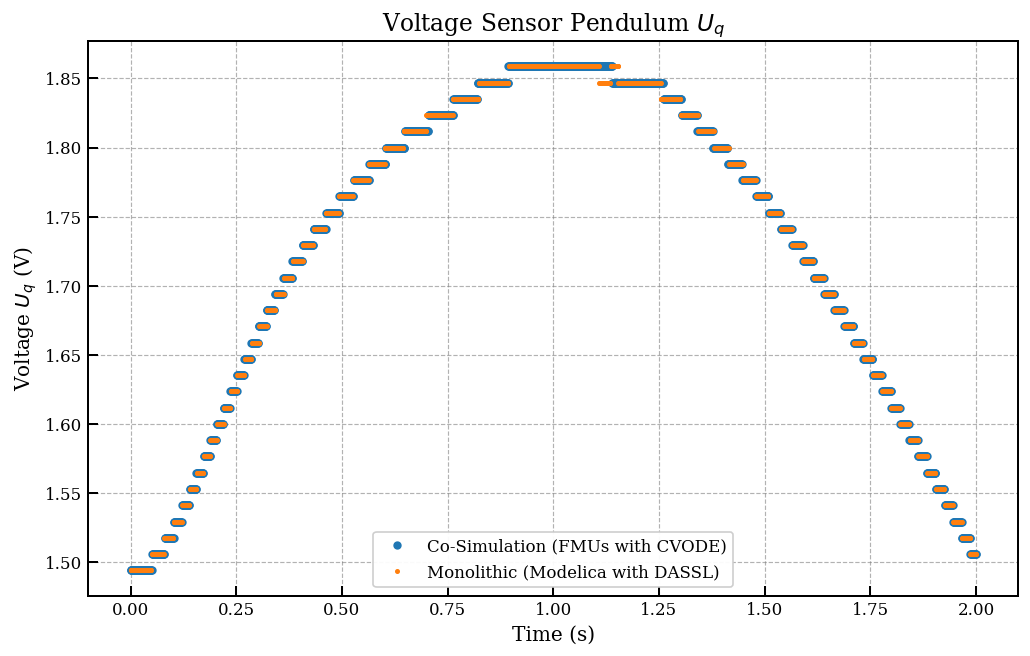

In [ ]:
# Sensor State Uq
t_vals_cs, Uq_state_cs = zip(*sensor_state.outputs['U_q'].history)
t_vals_cs = np.array(t_vals_cs)

Uq_state_cs = np.array([val.magnitude for val in Uq_state_cs])
t_vals_ref = np.array(results['time'])

Uq_state_vals_ref = np.array(results['sensor_state.U_q'])
Uq_state_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, Uq_state_vals_ref)
denom = np.max(np.abs(Uq_state_vals_ref_interp))
Uq_state_error = (Uq_state_cs - Uq_state_vals_ref_interp) / denom
max_error = np.max(np.abs(Uq_state_error))
print(f"Maximum relative error in Uq_state: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, Uq_state_cs, **cs_style)
plt.plot(t_vals_cs, Uq_state_vals_ref_interp, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel('Voltage $U_{q}$ (V)')
plt.title('Voltage Sensor Pendulum $U_{q}$')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in u_pid: 1.255e+00


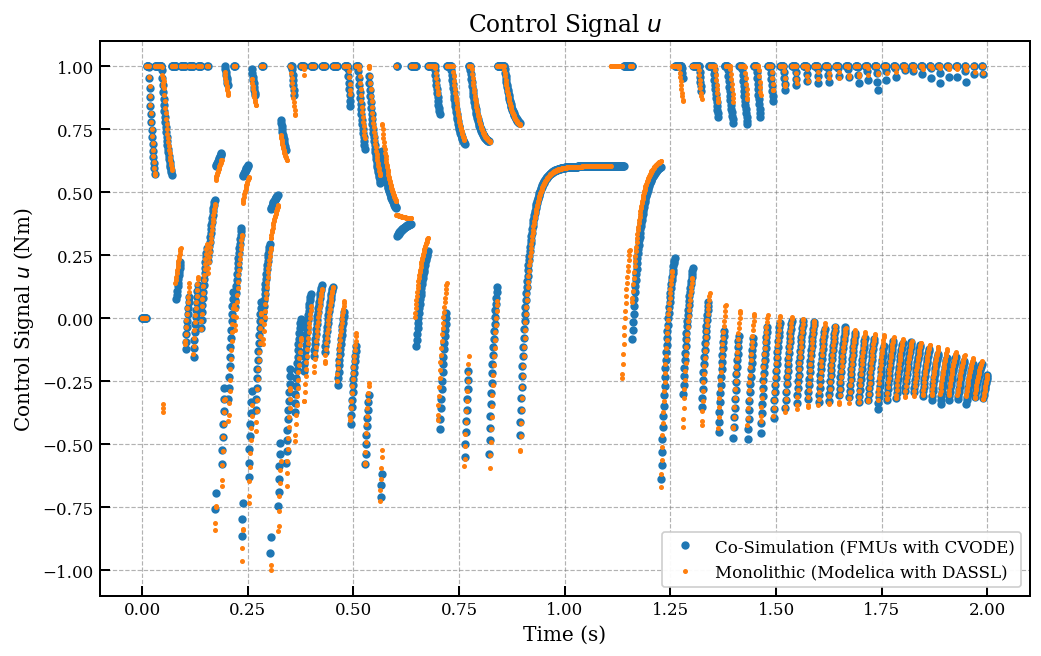

In [ ]:
# PID u
t_vals_cs, u_pid_cs = zip(*pid.outputs['u'].history)
t_vals_cs = np.array(t_vals_cs)
u_pid_cs = np.array(u_pid_cs)

t_vals_ref = np.array(results['time'])
u_pid_vals_ref = np.array(results['pid.u'])
u_pid_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, u_pid_vals_ref)

denom = np.max(np.abs(u_pid_vals_ref_interp))
u_pid_error = (u_pid_cs - u_pid_vals_ref_interp) / denom

max_error = np.max(np.abs(u_pid_error))
print(f"Maximum relative error in u_pid: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, u_pid_cs, **cs_style)
plt.plot(t_vals_ref, u_pid_vals_ref, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel('Control Signal $u$ (Nm)')
plt.title('Control Signal $u$')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in torque_drive: 1.106e+00


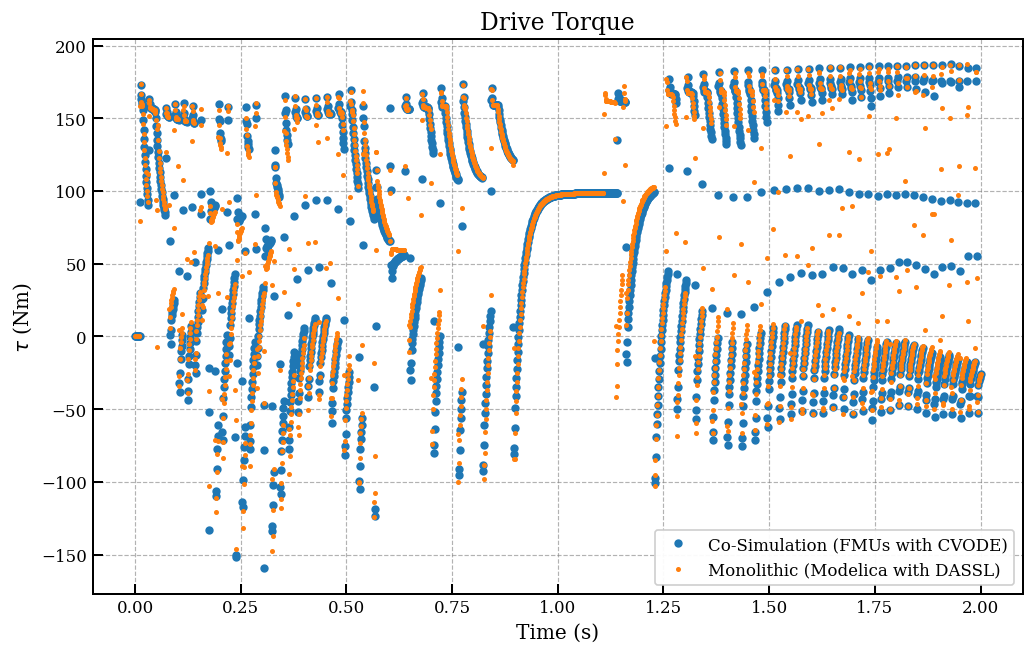

In [ ]:
# Drive torque
t_vals_cs, torque_drive_cs = zip(*drive_coupled.outputs['torque'].history)
t_vals_cs = np.array(t_vals_cs)
torque_drive_cs = np.array([val.magnitude for val in torque_drive_cs])

t_vals_ref = np.array(results['time'])
torque_drive_vals_ref = np.array(results['drive.torque'])
torque_drive_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, torque_drive_vals_ref)
denom = np.max(np.abs(torque_drive_vals_ref_interp))
torque_drive_error = (torque_drive_cs - torque_drive_vals_ref_interp) / denom

max_error = np.max(np.abs(torque_drive_error))
print(f"Maximum relative error in torque_drive: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, torque_drive_cs, **cs_style)
plt.plot(t_vals_cs, torque_drive_vals_ref_interp, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel(r'$\tau$ (Nm)')
plt.title('Drive Torque')
plt.legend()
plt.grid(True)
plt.show()

In [77]:
# Pendulum q
t_vals_cs, q_state_cs = zip(*pendulum.outputs['q'].history)
t_vals_cs = np.array(t_vals_cs)
q_state_cs = np.array([val.magnitude for val in q_state_cs])

t_vals_ref = np.array(results['time'])
q_state_vals_ref = np.array(results['pendulum.q'])
q_state_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, q_state_vals_ref)

# Errors
abs_error = np.abs(q_state_cs - q_state_vals_ref_interp)

eps = 1e-8
denom = np.maximum(np.abs(q_state_vals_ref_interp), eps)
rel_error = abs_error / denom

# summary metrics
max_abs = np.max(abs_error)
rmse = np.sqrt(np.mean((q_state_cs - q_state_vals_ref_interp)**2))
max_rel = np.max(rel_error)

print(f"RMSE: {rmse:.3e}")

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t_vals_cs, q_state_cs, **cs_style)
axs[0].plot(t_vals_ref, q_state_vals_ref, **modelica_style)
axs[0].set_ylabel(r'$q_{plant}$ (rad)')
axs[0].set_title(f'{mode} Algorithm: Pendulum Angle $q_{{plant}}$')
axs[0].legend()
axs[0].grid(True)

axs[1].semilogy(t_vals_cs, rel_error, **error_style)
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Relative error')
axs[1].grid(which='both')

plt.tight_layout()
plt.savefig(f"figures/cs_alg_verificationq_complex_{mode}.svg")
plt.show()


KeyError: 'time'